# 📈 Week 3 — Day 2: Linear Regression

**BinX Tech — AI & Machine Learning Internship Program**

![status](https://img.shields.io/badge/status-complete-brightgreen)
![phase](https://img.shields.io/badge/phase-2%20%7C%20Core%20ML%20Training-9146FF)
![python](https://img.shields.io/badge/python-3.10%2B-blue)
![libraries](https://img.shields.io/badge/libraries-Scikit--learn%20%7C%20Pandas%20%7C%20Matplotlib-orange)

---

| | |
|---|---|
| **Day** | Day 2 of 5 |
| **Duration** | 8 hours |
| **Tools** | Scikit-learn • Pandas • Matplotlib • Jupyter Notebook |
| **Dataset** | Diamonds (same dataset as Day 1) |

---

## 🎯 Learning Objectives

- Train a linear regression model and generate predictions.
- Interpret the model's coefficients and intercept.
- Evaluate a regression model with MAE, RMSE, and R² against a baseline.

---


## 🔧 Step 0 — Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
np.random.seed(42)
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 📂 Step 1 — Load Data and Recreate the Split from Day 1

Using the same features, target, and `random_state=42` split as Day 1, so results here are
directly comparable to what was established yesterday.


In [2]:
df = sns.load_dataset("diamonds")
feature_cols = ["carat", "depth", "table", "x", "y", "z"]

X = df[feature_cols]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (43152, 6) | Test shape: (10788, 6)


## 📖 Step 2 — What Linear Regression Does

Linear regression predicts a continuous number by fitting the best straight line (or hyperplane)
through the data. Its prediction is exactly the **dot product** from Week 2:

```
prediction = (feature₁ × weight₁) + (feature₂ × weight₂) + ... + bias
```

Training means finding the weights that make this line fit the data as closely as possible.

---

## ⚙️ Step 3 — Training and Predicting


In [3]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("Model trained ✅")
print("First 5 predictions:", np.round(predictions[:5], 2))
print("First 5 actual prices:", y_test.values[:5])


Model trained ✅
First 5 predictions: [  200.79  2361.44  1051.28  1229.93 10035.11]
First 5 actual prices: [ 559 2201 1238 1304 6901]


### 📝 Interpretation

Comparing the first five predictions to the actual prices, the model is clearly in the right
ballpark for most rows, but not exact — some predictions are off by a few hundred dollars. This is
expected: linear regression fits one straight relationship across the entire dataset, so it can't
perfectly capture every individual diamond's price, especially for diamonds where price depends on
combinations of features (like `carat` and `depth` together) rather than each feature acting
independently. The systematic evaluation in Step 5 below quantifies exactly how large this
typical error is.

---

## 🔍 Step 4 — Interpreting Coefficients

After fitting, each feature has a **coefficient** (its weight), and the model has one **intercept**
(the bias). A coefficient tells you how much the prediction changes when that feature increases by
one unit, holding all others constant.


In [4]:
coef_table = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Intercept (bias):", round(model.intercept_, 2))
coef_table


Intercept (bias): 20976.56


,Feature,Coefficient
0,carat,10683.184260
3,x,-1286.799574
1,depth,-204.099553
2,table,-104.267369
5,z,53.394864
4,y,37.632521


### 📝 Interpretation

`carat` has by far the largest coefficient (≈ **+10,683**), meaning that holding all other
features constant, each additional carat of weight adds roughly \$10,683 to the predicted price —
by far the strongest driver of price in this model, which matches what's expected physically:
carat (weight) is the single most important factor in diamond pricing.

Interestingly, `x` (one of the physical dimensions) has a large **negative** coefficient
(≈ **-1,287**), even though larger diamonds are generally more expensive. This isn't a
contradiction — it's a sign of **multicollinearity**: `carat`, `x`, `y`, and `z` are all highly
correlated with each other (a bigger diamond has both higher carat *and* larger dimensions), so
the model is splitting credit for "size" unevenly across these overlapping features rather than
each coefficient having a clean, independent real-world meaning. `depth` (-204) and `table`
(-104) have smaller negative effects, while `y` and `z` have small positive effects — consistent
with them playing a minor, secondary role once `carat` has already captured most of the size
signal.

---

## 📊 Step 5 — Regression Metrics


In [5]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

metrics_table = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [round(mae, 2), round(rmse, 2), round(r2, 4)]
})
metrics_table


,Metric,Value
0,MAE,888.480
1,RMSE,1497.390
2,R²,0.859


### 📝 Interpretation

- **MAE ≈ \$888** — on average, the model's price predictions are off by about \$888. Given that
  diamond prices in this dataset range from under \$400 to over \$18,000, this represents a
  moderate, usable level of error for many but not all diamonds.
- **RMSE ≈ \$1,497** — noticeably higher than the MAE, which signals that a number of predictions
  have much larger errors than the "typical" case (RMSE penalizes large errors more heavily). This
  is consistent with what we know from Week 2: diamond prices are right-skewed with expensive
  outliers, and those are exactly the rows a simple linear model struggles with most.
- **R² ≈ 0.859** — the model explains about **86% of the variance** in diamond prices using just
  six physical measurements. This is a strong result for a first, simple model — but the remaining
  ~14% is explained by factors this model doesn't include at all, most importantly `cut`, `color`,
  and `clarity` (categorical features not used here, since Day 1 focused on numeric features only).

---

## 📉 Step 6 — Comparing Against a Baseline

A model's metric means nothing in isolation — it must be compared against a simple baseline (e.g.
always predicting the mean) to prove it has actually learned something useful.


In [6]:
baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

comparison = pd.DataFrame({
    "Model": ["Baseline (predict mean)", "Linear Regression"],
    "MAE": [round(baseline_mae, 2), round(mae, 2)],
    "RMSE": [round(baseline_rmse, 2), round(rmse, 2)]
})
comparison


,Model,MAE,RMSE
0,Baseline (predict mean),3020.51,3987.22
1,Linear Regression,888.48,1497.39


### 📝 Interpretation

The baseline (always predicting the training mean of ≈\$3,939) produces an MAE of **≈\$3,021**
and an RMSE of **≈\$3,987** — both far worse than the linear regression model's MAE of **≈\$888**
and RMSE of **≈\$1,497**. The trained model cuts the average error by roughly **70%** compared to
just guessing the average price every time. This confirms the model has genuinely learned a
meaningful relationship between diamond size and price — it comfortably beats the baseline, so it
adds real predictive value rather than performing no better than a naive guess.

---

## 📈 Step 7 — Visualizing Predictions vs. Actual Prices


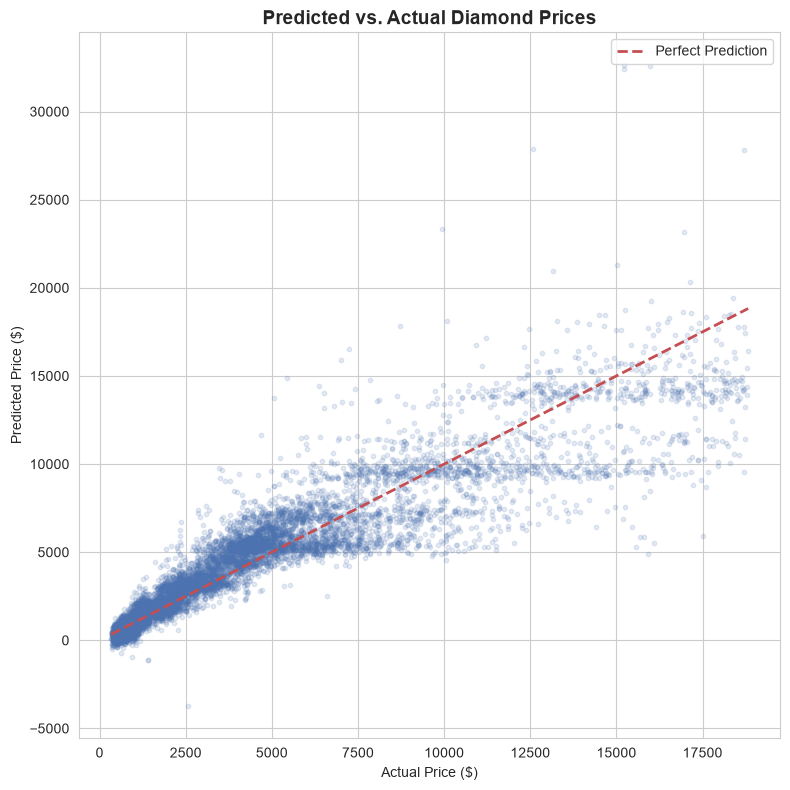

In [7]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions, alpha=0.15, s=10, color="#4C72B0")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="#C44E52", linestyle="--", linewidth=2, label="Perfect Prediction")
plt.title("Predicted vs. Actual Diamond Prices", fontsize=14, fontweight="bold")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.legend()
plt.tight_layout()
plt.show()


### 📝 Interpretation

Most points cluster tightly around the red dashed "perfect prediction" line for lower and
mid-range prices, confirming the model performs well there. However, the scatter widens
noticeably for higher-priced diamonds (above roughly \$10,000), where predictions become less
reliable and more spread out — this visually confirms what the RMSE-vs-MAE gap already suggested:
the model's errors are concentrated among expensive, outlier-heavy diamonds, exactly the segment
identified as right-skewed back in Week 2's EDA.

---

## ✅ Key Takeaways

- Linear regression achieved an R² of ≈0.86 using only six numeric physical features, explaining
  most — but not all — of the variation in diamond price, with `cut`, `color`, and `clarity`
  (unused here) likely accounting for the remaining gap.
- `carat` is overwhelmingly the strongest price driver (coefficient ≈ +10,683), consistent with
  real-world diamond pricing knowledge.
- The negative coefficient on `x` is not a real-world effect but a symptom of multicollinearity
  between `carat`, `x`, `y`, and `z` — a reminder that individual coefficients in a linear model
  can be misleading when features are highly correlated with each other.
- The model reduced average prediction error by about 70% compared to a naive baseline (always
  predicting the mean), confirming it learned genuine, useful patterns rather than just noise.
- The gap between MAE and RMSE, combined with the widening scatter at high prices, shows the
  model's weakest performance is concentrated among expensive diamonds — the same right-skewed
  outliers identified back in Week 2.

---

## 📚 Resources

| Resource | Type | Focus |
|---|---|---|
| [Linear Regression (Video)](https://www.youtube.com/watch?v=xLdvMG5qAmo) | Video | Core concepts covered today |
| [Scikit-learn — LinearRegression Docs](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) | Docs | Official API reference |

---

## ✍️ Author

**Zayan Shawareb**
BinX Tech — AI & Machine Learning Internship Program
Week 3, Day 2 — Linear Regression

---

## 🔗 Next Step

Proceed to **Day 3 — Logistic Regression & Classification Metrics**
